In [1]:
!pip install -q transformers accelerate datasets tiktoken pandas matplotlib psutil safetensors sentencepiece

In [2]:
import os
import gc
import time
import math
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

import tiktoken
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"

if device == "cuda":
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

print("Device:", device)

if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM GB:", torch.cuda.get_device_properties(0).total_memory / 1024**3)
    print("CUDA:", torch.version.cuda)
    print("PyTorch:", torch.__version__)

Device: cuda
GPU: NVIDIA RTX 6000 Ada Generation
VRAM GB: 47.98779296875
CUDA: 12.1
PyTorch: 2.5.1+cu121


In [3]:
# Main Logos checkpoint from your notebook
LOGOS_RUN_NAME = "logos_exp18_large_scaling_weight_tying_swiglu_15k_train"

LOGOS_OUT_DIR = Path("./logos_runs") / LOGOS_RUN_NAME

LOGOS_CKPT_PATH = LOGOS_OUT_DIR / "logos_large_scaling_weight_tying_swiglu_15k_train_best.pt"

DATA_DIR = Path("./data")
DATA_CACHE = DATA_DIR / "openwebtext_subset_100k.txt"

COMPARISON_OUT_DIR = Path("./logos_public_model_comparison")
COMPARISON_OUT_DIR.mkdir(parents=True, exist_ok=True)

# Evaluation settings
EVAL_TEXT_SAMPLES = 256        # Increase to 512/1024 for stronger paper results
CHARS_PER_SAMPLE = 1200
CONTEXT_LENGTH = 512
BATCH_SIZE_HF = 8              # With 48GB VRAM you can try 16 or 32
GEN_PROMPT = "The future of language models"
GEN_TOKENS = 100

# Logos architecture from your notebook
BLOCK_SIZE = 512
N_EMBD = 768
N_HEAD = 12
N_LAYER = 12
DROPOUT = 0.2
SWIGLU_HIDDEN = int((8 * N_EMBD) / 3)

enc = tiktoken.get_encoding("gpt2")
vocab_size = enc.n_vocab

print("Logos checkpoint:", LOGOS_CKPT_PATH)
print("Checkpoint exists:", LOGOS_CKPT_PATH.exists())
print("Vocab size:", vocab_size)

Logos checkpoint: logos_runs\logos_exp18_large_scaling_weight_tying_swiglu_15k_train\logos_large_scaling_weight_tying_swiglu_15k_train_best.pt
Checkpoint exists: True
Vocab size: 50257


In [4]:
DATA_DIR.mkdir(parents=True, exist_ok=True)

if DATA_CACHE.exists():
    print("Using existing OpenWebText cache:", DATA_CACHE)
    text = DATA_CACHE.read_text(encoding="utf-8", errors="ignore")
else:
    print("No cache found. Downloading small OpenWebText subset for evaluation...")
    dataset = load_dataset("openwebtext", split="train", streaming=True)

    samples = []
    for i, sample in enumerate(dataset):
        if i >= 10000:
            break

        txt = sample.get("text", "")
        if isinstance(txt, str) and len(txt.strip()) > 100:
            samples.append(txt.strip())

    text = "\n\n".join(samples)
    DATA_CACHE.write_text(text, encoding="utf-8")

# Use last 10% as validation, same logic as your notebook
n = int(0.9 * len(text))
val_text = text[n:]

print("Total characters:", len(text))
print("Validation characters:", len(val_text))

# Build raw text chunks for fair external model comparison
eval_texts = []

start = 0
while len(eval_texts) < EVAL_TEXT_SAMPLES and start + CHARS_PER_SAMPLE < len(val_text):
    chunk = val_text[start:start + CHARS_PER_SAMPLE].strip()
    start += CHARS_PER_SAMPLE

    if len(chunk) > 200:
        eval_texts.append(chunk)

print("Evaluation text samples:", len(eval_texts))
print("Sample preview:\n")
print(eval_texts[0][:500])

Using existing OpenWebText cache: data\openwebtext_subset_100k.txt
Total characters: 492672887
Validation characters: 49267289
Evaluation text samples: 256
Sample preview:

n necessary.

One of the challenges facing the current generation of educators, students, progressives, and other cultural workers is the need to address the role they might play in educating students to be critically engaged agents, attentive to addressing important social issues and being alert to the responsibility of deepening and expanding the meaning and practices of a vibrant democracy. At the heart of such a challenge is the question of what education should accomplish not simply in a de


In [5]:
class CausalSelfAttention(nn.Module):
    def __init__(self, n_embd, n_head, dropout):
        super().__init__()

        assert n_embd % n_head == 0

        self.n_head = n_head
        self.head_dim = n_embd // n_head

        self.qkv = nn.Linear(n_embd, 3 * n_embd, bias=False)
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = dropout
        self.resid_dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape

        q, k, v = self.qkv(x).split(C, dim=2)

        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)

        y = F.scaled_dot_product_attention(
            q,
            k,
            v,
            attn_mask=None,
            dropout_p=self.dropout if self.training else 0.0,
            is_causal=True
        )

        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.proj(y))

        return y


class SwiGLUFeedForward(nn.Module):
    def __init__(self, n_embd, hidden_dim, dropout):
        super().__init__()

        self.gate_proj = nn.Linear(n_embd, hidden_dim)
        self.up_proj = nn.Linear(n_embd, hidden_dim)
        self.down_proj = nn.Linear(hidden_dim, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        gate = F.silu(self.gate_proj(x))
        value = self.up_proj(x)

        x = gate * value
        x = self.down_proj(x)
        x = self.dropout(x)

        return x


class TransformerBlock(nn.Module):
    def __init__(self, n_embd, n_head, dropout, swiglu_hidden):
        super().__init__()

        self.ln1 = nn.LayerNorm(n_embd)
        self.attn = CausalSelfAttention(n_embd, n_head, dropout)

        self.ln2 = nn.LayerNorm(n_embd)
        self.ffn = SwiGLUFeedForward(n_embd, swiglu_hidden, dropout)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ffn(self.ln2(x))
        return x


class LogosLargeScaling15KTrainLM(nn.Module):
    def __init__(self):
        super().__init__()

        self.token_embedding = nn.Embedding(vocab_size, N_EMBD)
        self.position_embedding = nn.Embedding(BLOCK_SIZE, N_EMBD)

        self.blocks = nn.Sequential(
            *[
                TransformerBlock(N_EMBD, N_HEAD, DROPOUT, SWIGLU_HIDDEN)
                for _ in range(N_LAYER)
            ]
        )

        self.ln_f = nn.LayerNorm(N_EMBD)
        self.lm_head = nn.Linear(N_EMBD, vocab_size, bias=False)

        self.apply(self._init_weights)

        # Weight tying
        self.lm_head.weight = self.token_embedding.weight

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

            if module.bias is not None:
                nn.init.zeros_(module.bias)

        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        tok_emb = self.token_embedding(idx)

        pos = torch.arange(T, device=idx.device)
        pos_emb = self.position_embedding(pos)

        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_f(x)

        logits = self.lm_head(x)

        loss = None

        if targets is not None:
            loss = F.cross_entropy(
                logits.view(B * T, vocab_size),
                targets.view(B * T)
            )

        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=0.9, top_k=40, top_p=0.9):
        self.eval()

        for _ in range(max_new_tokens):
            idx_cond = idx[:, -BLOCK_SIZE:]

            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature

            if top_k is not None:
                k = min(top_k, logits.size(-1))
                top_values, _ = torch.topk(logits, k)
                logits[logits < top_values[:, [-1]]] = float("-inf")

            if top_p is not None and top_p < 1.0:
                sorted_logits, sorted_indices = torch.sort(logits, descending=True, dim=-1)
                sorted_probs = F.softmax(sorted_logits, dim=-1)
                cumulative_probs = torch.cumsum(sorted_probs, dim=-1)

                sorted_indices_to_remove = cumulative_probs > top_p
                sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
                sorted_indices_to_remove[..., 0] = 0

                sorted_logits[sorted_indices_to_remove] = float("-inf")
                logits = torch.zeros_like(logits).scatter(1, sorted_indices, sorted_logits)

            probs = F.softmax(logits, dim=-1)
            next_idx = torch.multinomial(probs, num_samples=1)

            idx = torch.cat([idx, next_idx], dim=1)

        return idx


def count_parameters(model):
    return sum(p.numel() for p in model.parameters())


def model_weight_memory_mb(model):
    total_bytes = 0
    for p in model.parameters():
        total_bytes += p.numel() * p.element_size()
    return total_bytes / (1024 ** 2)


def file_size_mb(path):
    path = Path(path)
    if not path.exists():
        return None
    return path.stat().st_size / (1024 ** 2)

In [6]:
def cleanup_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()


@torch.no_grad()
def evaluate_logos_model(model, eval_texts, max_length=512):
    model.eval()

    total_nll = 0.0
    total_tokens = 0
    total_bytes = 0

    for raw_text in eval_texts:
        ids = enc.encode_ordinary(raw_text)

        if len(ids) < 2:
            continue

        ids = ids[:max_length + 1]
        actual_text = enc.decode(ids)

        x_ids = torch.tensor(ids[:-1], dtype=torch.long, device=device).unsqueeze(0)
        y_ids = torch.tensor(ids[1:], dtype=torch.long, device=device).unsqueeze(0)

        with torch.amp.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(device == "cuda")
        ):
            _, loss = model(x_ids, y_ids)

        n_tokens = y_ids.numel()
        total_nll += loss.item() * n_tokens
        total_tokens += n_tokens
        total_bytes += len(actual_text.encode("utf-8", errors="ignore"))

    avg_nll = total_nll / total_tokens
    ppl = math.exp(avg_nll)
    bits_per_byte = total_nll / math.log(2) / total_bytes

    return {
        "eval_loss": avg_nll,
        "perplexity": ppl,
        "bits_per_byte": bits_per_byte,
        "eval_tokens": total_tokens,
        "eval_bytes": total_bytes,
    }


@torch.no_grad()
def evaluate_hf_model(model, tokenizer, eval_texts, max_length=512, batch_size=8):
    model.eval()

    total_nll = 0.0
    total_tokens = 0
    total_bytes = 0

    for i in range(0, len(eval_texts), batch_size):
        batch_texts = eval_texts[i:i + batch_size]

        encoded = tokenizer(
            batch_texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_length + 1
        )

        input_ids = encoded["input_ids"].to(device)
        attention_mask = encoded["attention_mask"].to(device)

        labels = input_ids.clone()
        labels[attention_mask == 0] = -100

        with torch.amp.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(device == "cuda")
        ):
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss

        # HF causal LM loss internally shifts labels.
        n_tokens = attention_mask[:, 1:].sum().item()

        total_nll += loss.item() * n_tokens
        total_tokens += n_tokens

        for row_ids, row_mask in zip(input_ids, attention_mask):
            actual_ids = row_ids[row_mask.bool()].detach().cpu().tolist()
            actual_text = tokenizer.decode(actual_ids, skip_special_tokens=False)
            total_bytes += len(actual_text.encode("utf-8", errors="ignore"))

    avg_nll = total_nll / total_tokens
    ppl = math.exp(avg_nll)
    bits_per_byte = total_nll / math.log(2) / total_bytes

    return {
        "eval_loss": avg_nll,
        "perplexity": ppl,
        "bits_per_byte": bits_per_byte,
        "eval_tokens": total_tokens,
        "eval_bytes": total_bytes,
    }


@torch.no_grad()
def benchmark_logos_generation(model, prompt=GEN_PROMPT, max_new_tokens=100):
    model.eval()

    idx = torch.tensor([enc.encode_ordinary(prompt)], dtype=torch.long, device=device)

    # Warmup
    _ = model.generate(idx, max_new_tokens=10)

    if device == "cuda":
        torch.cuda.synchronize()

    start = time.time()

    out = model.generate(idx, max_new_tokens=max_new_tokens)

    if device == "cuda":
        torch.cuda.synchronize()

    elapsed = time.time() - start

    return {
        "generation_tokens_per_sec": max_new_tokens / elapsed,
        "generation_ms_per_token": (elapsed / max_new_tokens) * 1000,
        "sample_text": enc.decode(out[0].detach().cpu().tolist()),
    }


@torch.no_grad()
def benchmark_hf_generation(model, tokenizer, prompt=GEN_PROMPT, max_new_tokens=100):
    model.eval()

    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    # Warmup
    _ = model.generate(
        **inputs,
        max_new_tokens=10,
        do_sample=True,
        temperature=0.9,
        top_k=40,
        top_p=0.9,
        pad_token_id=tokenizer.eos_token_id
    )

    if device == "cuda":
        torch.cuda.synchronize()

    start = time.time()

    out = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=0.9,
        top_k=40,
        top_p=0.9,
        pad_token_id=tokenizer.eos_token_id
    )

    if device == "cuda":
        torch.cuda.synchronize()

    elapsed = time.time() - start

    return {
        "generation_tokens_per_sec": max_new_tokens / elapsed,
        "generation_ms_per_token": (elapsed / max_new_tokens) * 1000,
        "sample_text": tokenizer.decode(out[0], skip_special_tokens=True),
    }

In [7]:
if not LOGOS_CKPT_PATH.exists():
    raise FileNotFoundError(
        f"Logos checkpoint not found at: {LOGOS_CKPT_PATH}\n"
        "Run your Exp18 training cells first or update LOGOS_CKPT_PATH."
    )

cleanup_gpu()

logos_model = LogosLargeScaling15KTrainLM().to(device)

checkpoint = torch.load(LOGOS_CKPT_PATH, map_location=device)

if "model_state_dict" in checkpoint:
    logos_model.load_state_dict(checkpoint["model_state_dict"])
else:
    logos_model.load_state_dict(checkpoint)

logos_model.eval()

logos_param_count = count_parameters(logos_model)
logos_ckpt_mb = file_size_mb(LOGOS_CKPT_PATH)
logos_weight_memory_mb = model_weight_memory_mb(logos_model)

if device == "cuda":
    torch.cuda.reset_peak_memory_stats()

logos_eval = evaluate_logos_model(
    model=logos_model,
    eval_texts=eval_texts,
    max_length=CONTEXT_LENGTH
)

logos_gen = benchmark_logos_generation(
    model=logos_model,
    prompt=GEN_PROMPT,
    max_new_tokens=GEN_TOKENS
)

logos_peak_vram_mb = None
if device == "cuda":
    logos_peak_vram_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)

logos_result = {
    "model": "Logos Exp18",
    "source": "local_checkpoint",
    "params": logos_param_count,
    "params_m": logos_param_count / 1e6,
    "checkpoint_mb": logos_ckpt_mb,
    "weight_memory_mb": logos_weight_memory_mb,
    "context_length": CONTEXT_LENGTH,
    "eval_loss": logos_eval["eval_loss"],
    "perplexity": logos_eval["perplexity"],
    "bits_per_byte": logos_eval["bits_per_byte"],
    "eval_tokens": logos_eval["eval_tokens"],
    "eval_bytes": logos_eval["eval_bytes"],
    "generation_ms_per_token": logos_gen["generation_ms_per_token"],
    "generation_tokens_per_sec": logos_gen["generation_tokens_per_sec"],
    "peak_vram_mb": logos_peak_vram_mb,
}

print(json.dumps(logos_result, indent=2))

print("\n=== Logos Sample Generation ===\n")
print(logos_gen["sample_text"])

C:\Users\guest1\AppData\Local\Temp\ipykernel_2884\2612436174.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(LOGOS_CKPT_PATH, map_location=devic

{
  "model": "Logos Exp18",
  "source": "local_checkpoint",
  "params": 124031232,
  "params_m": 124.031232,
  "checkpoint_mb": 473.2041759490967,
  "weight_memory_mb": 473.1416015625,
  "context_length": 512,
  "eval_loss": 4.1217965601499476,
  "perplexity": 61.66993655064014,
  "bits_per_byte": 1.285816513678678,
  "eval_tokens": 66917,
  "eval_bytes": 309470,
  "generation_ms_per_token": 9.151637554168701,
  "generation_tokens_per_sec": 109.27006167814041,
  "peak_vram_mb": 1372.46630859375
}

=== Logos Sample Generation ===

The future of language models and the future of religion is not enough, but with the help of the public sector, the future of language models, and future of languages in the United States.

The U.S. is looking to expand the world’s ability to provide more information about the future of languages and the future of language models. This could be the key to modernizing language models in the United States.

The U.S. is a new and improved language, with more than

In [8]:
HF_BASELINES = [
    {
        "name": "GPT-2 Small",
        "model_id": "openai-community/gpt2",
    },
    {
        "name": "Pythia-70M Deduped",
        "model_id": "EleutherAI/pythia-70m-deduped",
    },
    {
        "name": "Pythia-160M Deduped",
        "model_id": "EleutherAI/pythia-160m-deduped",
    },
    {
        "name": "SmolLM2-135M",
        "model_id": "HuggingFaceTB/SmolLM2-135M",
    },
]

hf_results = []

for item in HF_BASELINES:
    cleanup_gpu()

    name = item["name"]
    model_id = item["model_id"]

    print("\n" + "=" * 80)
    print("Loading:", name, "|", model_id)

    tokenizer = AutoTokenizer.from_pretrained(model_id, use_fast=True)

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        torch_dtype=torch.float16 if device == "cuda" else torch.float32,
        low_cpu_mem_usage=True
    ).to(device)

    model.eval()

    param_count = count_parameters(model)
    weight_mb = model_weight_memory_mb(model)

    if device == "cuda":
        torch.cuda.reset_peak_memory_stats()

    eval_result = evaluate_hf_model(
        model=model,
        tokenizer=tokenizer,
        eval_texts=eval_texts,
        max_length=CONTEXT_LENGTH,
        batch_size=BATCH_SIZE_HF
    )

    gen_result = benchmark_hf_generation(
        model=model,
        tokenizer=tokenizer,
        prompt=GEN_PROMPT,
        max_new_tokens=GEN_TOKENS
    )

    peak_vram_mb = None
    if device == "cuda":
        peak_vram_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)

    row = {
        "model": name,
        "source": model_id,
        "params": param_count,
        "params_m": param_count / 1e6,
        "checkpoint_mb": None,
        "weight_memory_mb": weight_mb,
        "context_length": CONTEXT_LENGTH,
        "eval_loss": eval_result["eval_loss"],
        "perplexity": eval_result["perplexity"],
        "bits_per_byte": eval_result["bits_per_byte"],
        "eval_tokens": eval_result["eval_tokens"],
        "eval_bytes": eval_result["eval_bytes"],
        "generation_ms_per_token": gen_result["generation_ms_per_token"],
        "generation_tokens_per_sec": gen_result["generation_tokens_per_sec"],
        "peak_vram_mb": peak_vram_mb,
    }

    hf_results.append(row)

    print(json.dumps(row, indent=2))

    print("\n=== Sample Generation ===\n")
    print(gen_result["sample_text"][:2000])

    del model
    del tokenizer
    cleanup_gpu()


Loading: GPT-2 Small | openai-community/gpt2


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

C:\Users\guest1\Desktop\projojo\.venv\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\guest1\.cache\huggingface\hub\models--openai-community--gpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/269M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

{
  "model": "SmolLM2-135M",
  "source": "HuggingFaceTB/SmolLM2-135M",
  "params": 134515008,
  "params_m": 134.515008,
  "checkpoint_mb": null,
  "weight_memory_mb": 256.5670166015625,
  "context_length": 512,
  "eval_loss": 3.1487286119364137,
  "perplexity": 23.306414239522475,
  "bits_per_byte": 1.005235112369946,
  "eval_tokens": 68482,
  "eval_bytes": 309470,
  "generation_ms_per_token": 59.593589305877686,
  "generation_tokens_per_sec": 16.78032841531447,
  "peak_vram_mb": 3097.70458984375
}

=== Sample Generation ===

The future of language models

We believe that the future of the technology will be very different from that of the past. This will come about because of the changes which are happening in the field of artificial intelligence. One of the most important changes is that of the internet of things, and that is where we are already seeing a lot of use of these technologies in order to ensure the smooth functioning of our lives and our communities.

With the rise of the

In [9]:
all_results = [logos_result] + hf_results

comparison_df = pd.DataFrame(all_results)

# Lower is better for these:
# - bits_per_byte
# - perplexity, but tokenizer-specific
# - generation_ms_per_token
# - peak_vram_mb
# - weight_memory_mb

comparison_df["rank_by_bpb"] = comparison_df["bits_per_byte"].rank(
    ascending=True,
    method="min"
).astype(int)

comparison_df["rank_by_ppl_tokenizer_specific"] = comparison_df["perplexity"].rank(
    ascending=True,
    method="min"
).astype(int)

comparison_df["rank_by_latency"] = comparison_df["generation_ms_per_token"].rank(
    ascending=True,
    method="min"
).astype(int)

comparison_df["rank_by_vram"] = comparison_df["peak_vram_mb"].rank(
    ascending=True,
    method="min"
).astype(int)

comparison_df = comparison_df.sort_values("bits_per_byte", ascending=True).reset_index(drop=True)

display(comparison_df)

csv_path = COMPARISON_OUT_DIR / "logos_vs_public_models_comparison.csv"
json_path = COMPARISON_OUT_DIR / "logos_vs_public_models_comparison.json"

comparison_df.to_csv(csv_path, index=False)

with open(json_path, "w", encoding="utf-8") as f:
    json.dump(all_results, f, indent=2)

print("Saved CSV:", csv_path)
print("Saved JSON:", json_path)

,model,source,params,params_m,checkpoint_mb,weight_memory_mb,context_length,eval_loss,perplexity,bits_per_byte,eval_tokens,eval_bytes,generation_ms_per_token,generation_tokens_per_sec,peak_vram_mb,rank_by_bpb,rank_by_ppl_tokenizer_specific,rank_by_latency,rank_by_vram
0,SmolLM2-135M,HuggingFaceTB/SmolLM2-135M,134515008,134.515008,NaN,256.567017,512,3.148729,23.306414,1.005235,68482,309470,59.593589,16.780328,3097.704590,1,1,5,4
1,Pythia-160M Deduped,EleutherAI/pythia-160m-deduped,162322944,162.322944,NaN,309.606445,512,3.423004,30.661398,1.072676,67221,309470,21.622245,46.248666,3054.394043,2,2,4,3
2,GPT-2 Small,openai-community/gpt2,124439808,124.439808,NaN,237.350098,512,3.444259,31.320076,1.074455,66917,309470,14.890077,67.158819,3099.007812,3,3,3,5
3,Pythia-70M Deduped,EleutherAI/pythia-70m-deduped,70426624,70.426624,NaN,134.328125,512,3.889043,48.864082,1.218719,67221,309470,11.544628,86.620373,2746.617676,4,4,2,2
4,Logos Exp18,local_checkpoint,124031232,124.031232,473.204176,473.141602,512,4.121797,61.669937,1.285817,66917,309470,9.151638,109.270062,1372.466309,5,5,1,1


Saved CSV: logos_public_model_comparison\logos_vs_public_models_comparison.csv
Saved JSON: logos_public_model_comparison\logos_vs_public_models_comparison.json


In [10]:
score_df = comparison_df.copy()

# Use bits_per_byte as the main cross-tokenizer quality score.
# PPL is kept, but it is less fair across different tokenizers.
best_bpb = score_df["bits_per_byte"].min()
best_latency = score_df["generation_ms_per_token"].min()
best_vram = score_df["peak_vram_mb"].min()
best_weight_mem = score_df["weight_memory_mb"].min()
best_params = score_df["params_m"].min()

score_df["quality_score_bpb"] = best_bpb / score_df["bits_per_byte"]
score_df["latency_score"] = best_latency / score_df["generation_ms_per_token"]
score_df["vram_score"] = best_vram / score_df["peak_vram_mb"]
score_df["memory_score"] = best_weight_mem / score_df["weight_memory_mb"]
score_df["parameter_score"] = best_params / score_df["params_m"]

score_df["external_efficiency_score"] = (
    0.45 * score_df["quality_score_bpb"] +
    0.20 * score_df["latency_score"] +
    0.15 * score_df["vram_score"] +
    0.10 * score_df["memory_score"] +
    0.10 * score_df["parameter_score"]
)

score_df["external_efficiency_rank"] = score_df["external_efficiency_score"].rank(
    ascending=False,
    method="min"
).astype(int)

score_df = score_df.sort_values("external_efficiency_score", ascending=False).reset_index(drop=True)

display(score_df)

score_csv_path = COMPARISON_OUT_DIR / "logos_external_efficiency_ranking.csv"
score_df.to_csv(score_csv_path, index=False)

print("Saved efficiency ranking:", score_csv_path)

,model,source,params,params_m,checkpoint_mb,weight_memory_mb,context_length,eval_loss,perplexity,bits_per_byte,...,rank_by_ppl_tokenizer_specific,rank_by_latency,rank_by_vram,quality_score_bpb,latency_score,vram_score,memory_score,parameter_score,external_efficiency_score,external_efficiency_rank
0,Pythia-70M Deduped,EleutherAI/pythia-70m-deduped,70426624,70.426624,NaN,134.328125,512,3.889043,48.864082,1.218719,...,4,2,2,0.824829,0.792718,0.499693,1.000000,1.000000,0.804671,1
1,Logos Exp18,local_checkpoint,124031232,124.031232,473.204176,473.141602,512,4.121797,61.669937,1.285817,...,5,1,1,0.781787,1.000000,1.000000,0.283907,0.567814,0.786976,2
2,GPT-2 Small,openai-community/gpt2,124439808,124.439808,NaN,237.350098,512,3.444259,31.320076,1.074455,...,3,3,5,0.935577,0.614613,0.442873,0.565949,0.565949,0.723553,3
3,Pythia-160M Deduped,EleutherAI/pythia-160m-deduped,162322944,162.322944,NaN,309.606445,512,3.423004,30.661398,1.072676,...,2,4,3,0.937129,0.423251,0.449342,0.433867,0.433867,0.660533,4
4,SmolLM2-135M,HuggingFaceTB/SmolLM2-135M,134515008,134.515008,NaN,256.567017,512,3.148729,23.306414,1.005235,...,1,5,4,1.000000,0.153567,0.443059,0.523560,0.523560,0.651884,5


Saved efficiency ranking: logos_public_model_comparison\logos_external_efficiency_ranking.csv


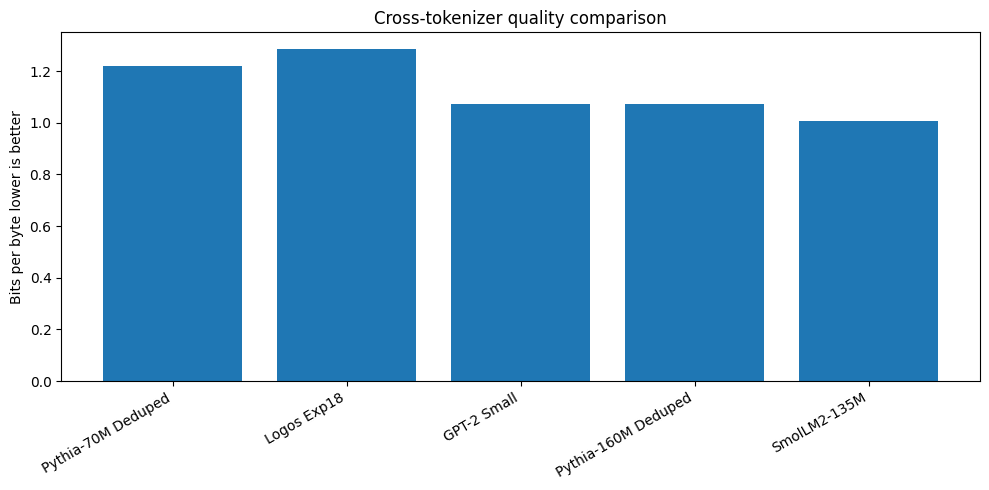

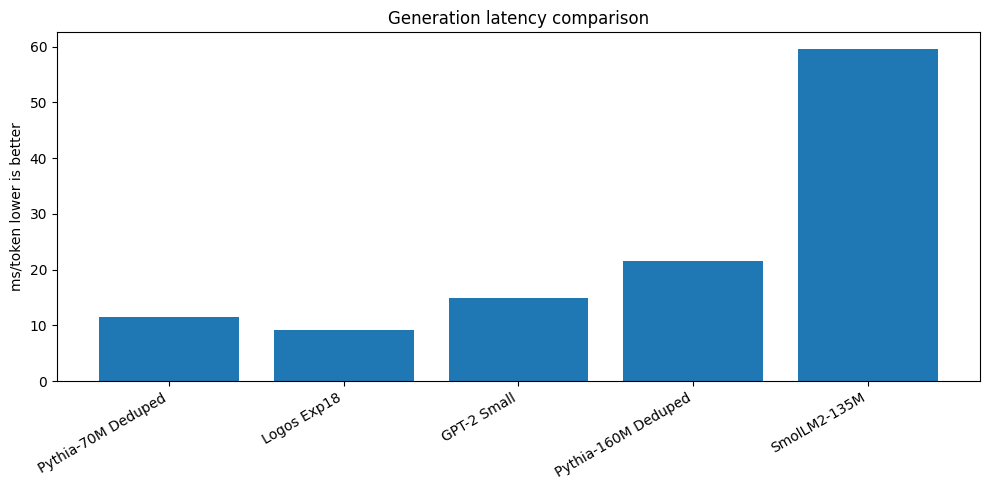

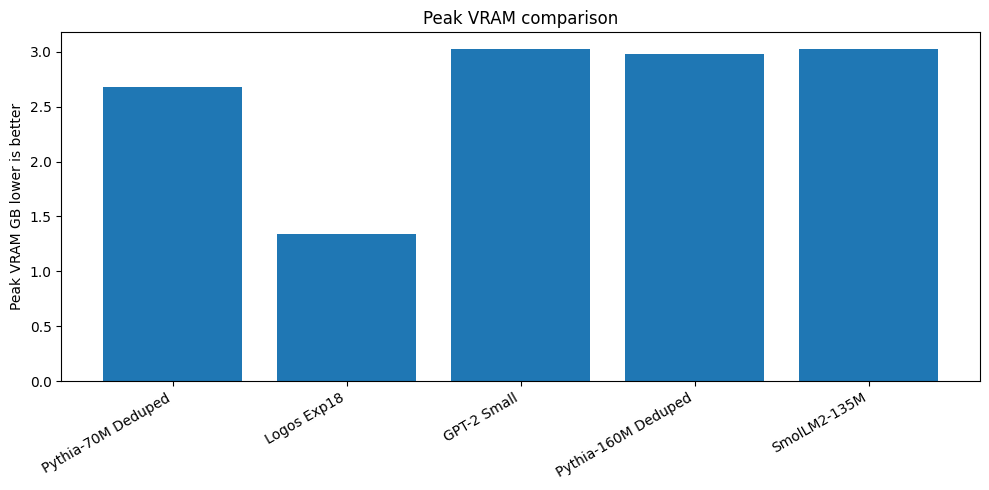

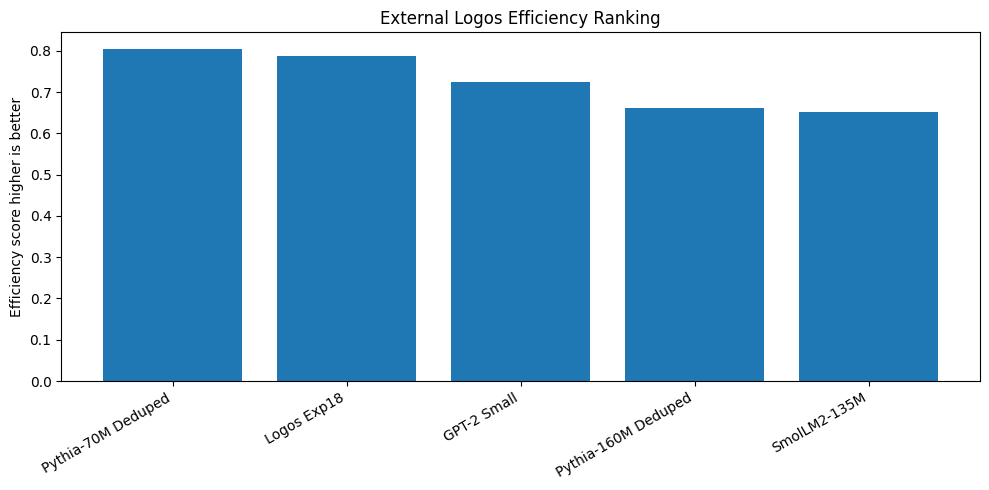

In [11]:
plot_df = score_df.copy()

plt.figure(figsize=(10, 5))
plt.bar(plot_df["model"], plot_df["bits_per_byte"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Bits per byte lower is better")
plt.title("Cross-tokenizer quality comparison")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(plot_df["model"], plot_df["generation_ms_per_token"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("ms/token lower is better")
plt.title("Generation latency comparison")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(plot_df["model"], plot_df["peak_vram_mb"] / 1024)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Peak VRAM GB lower is better")
plt.title("Peak VRAM comparison")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(plot_df["model"], plot_df["external_efficiency_score"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Efficiency score higher is better")
plt.title("External Logos Efficiency Ranking")
plt.tight_layout()
plt.show()

In [12]:
OPTIONAL_LARGER_BASELINES = [
    {
        "name": "GPT-2 Medium",
        "model_id": "openai-community/gpt2-medium",
    },
    {
        "name": "Pythia-410M Deduped",
        "model_id": "EleutherAI/pythia-410m-deduped",
    },
    {
        "name": "SmolLM2-360M",
        "model_id": "HuggingFaceTB/SmolLM2-360M",
    },
]

# To run, replace HF_BASELINES with OPTIONAL_LARGER_BASELINES in Cell 8.
# Or append them:
# HF_BASELINES = HF_BASELINES + OPTIONAL_LARGER_BASELINES